In [1]:
import quimb as qu
import quimb.tensor as qtn

Creating a tensor 


In [5]:
data = qu.bell_state('psi-').reshape(2, 2)
print(data)
inds = ('k0', 'k1')
tags = ('KET',)

ket = qtn.Tensor(data=data, inds=inds, tags=tags)
ket

[[ 0.      +0.j  0.707107+0.j]
 [-0.707107+0.j  0.      +0.j]]


Tensor(shape=(2, 2), inds=('k0', 'k1'), tags=oset(['KET']))

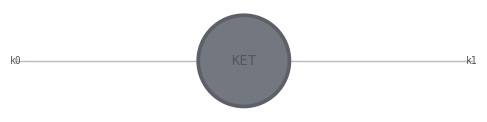

In [6]:
ket.draw()

Create a ket 

In [7]:
bra = qtn.Tensor(qu.rand_ket(4).reshape(2, 2), inds=('b0', 'b1'), tags=['BRA'])
print(bra)

Tensor(shape=(2, 2), inds=('b0', 'b1'), tags=oset(['BRA']), backend='numpy', dtype='complex128')


# OBJECTIF : 
Définir des circuits quantiques aléatoires
Avec des nombres de qubits faibles 
limité à des bonds valeurs singulières faibles

Pour différents chi, calculer phi MPS(chi)

pour différents D aussi 

on est censés obtenir des résultats qui décroissent en fonction de 

# créer 2 tenseurs qui interagissent via 1 réseau de tenseurs 
### ici ils sont liés via x avec un bond de dimension 3 et on crée un TN via la méthode qtn.TN


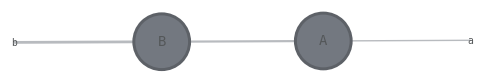

In [8]:
ta = qtn.rand_tensor([2, 3], inds=['a', 'x'], tags='A')
tb = qtn.rand_tensor([4, 3], inds=['b', 'x'], tags='B')

mps = qtn.TensorNetwork([ta, tb])
mps.draw()


# Ici on peut les contracter avec @

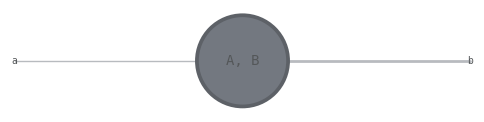

In [9]:
# matrix multiplication but with indices aligned automatically
mps_bis = qtn.TensorNetwork([ta @ tb])
mps_bis.draw()

# créer un MPS random et calculer sa norme de frobenius

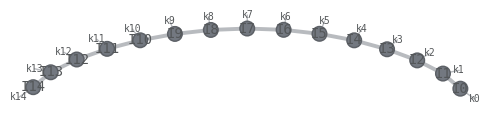

0.9999999999999988

In [10]:
# get a normalized tensor network
psi = qtn.MPS_rand_state(15, 7)

psi.draw()
# compute its norm squared
psi.H @ psi  # == (tn.H & tn) ^ ...


# Pour décomposer un tenseur : tensor_split 

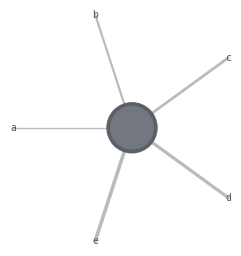

In [11]:
# create a tensor with 5 legs
t = qtn.rand_tensor([2, 3, 4, 5, 6], inds=['a', 'b', 'c', 'd', 'e'])
t.draw(figsize=(3, 3))

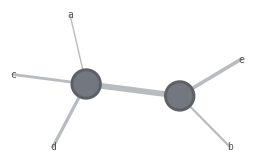

In [12]:
# split the tensor, by grouping some indices as 'left'
tn = t.split(['a', 'c', 'd'])
tn.draw(figsize=(3, 3))

## créer un TN en mode "graphe"

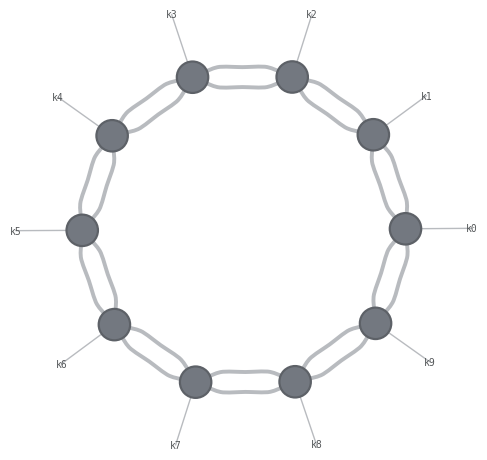

In [13]:
L = 10

# create the nodes, by default just the scalar 1.0
tensors = [qtn.Tensor() for _ in range(L)]

for i in range(L):
    # add the physical indices, each of size 2
    tensors[i].new_ind(f'k{i}', size=2)

    # add bonds between neighbouring tensors, of size 7
    tensors[i].new_bond(tensors[(i + 1) % L], size=7)
    tensors[i].new_bond(tensors[(i - 1) % L], size=7)


mps = qtn.TensorNetwork(tensors)
# mps.draw()

# mps ^ 

mps.draw()


# Créer une structure d'arbre 

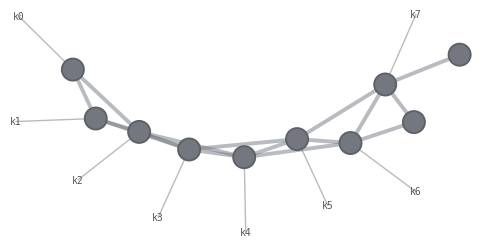

In [14]:
L = 10

# create the nodes, by default just the scalar 1.0
tensors = [qtn.Tensor() for _ in range(L)]

for i in range(L-2):
    # add the physical indices, each of size 2
    tensors[i].new_ind(f'k{i}', size=2)

    # add bonds between neighbouring tensors, of size 7
    tensors[i].new_bond(tensors[i + 1], size=7)
    tensors[i].new_bond(tensors[i + 2], size=7)

    # if i-1 >0 : 
    #     tensors[i].new_bond(tensors[i - 1], size=7)
    


mps = qtn.TensorNetwork(tensors)
# mps.draw()

# mps ^ 

mps.draw()


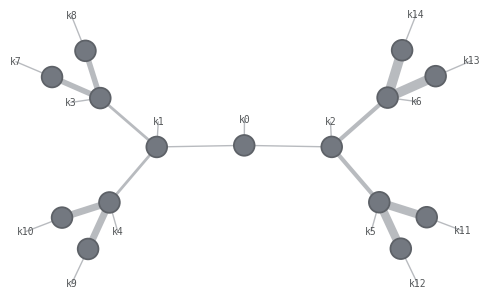

In [31]:

L = 15  # Nombre total de nœuds dans l'arbre

# 1. Création des nœuds du réseau sous forme de tenseurs
tensors = [qtn.Tensor(data=1.0) for _ in range(L)]  # Valeur initiale 1.0 pour éviter les problèmes

# 2. Organisation en structure d'arbre binaire
for i in range(L):
    # Ajouter un indice physique à chaque tenseur (dimension 2)
    tensors[i].new_ind(f'k{i}', size=2)
    
    # Connexion dans une structure d'arbre binaire
    left_child = 2 * i + 1
    right_child = 2 * i + 2
    
    if left_child < L:
        tensors[i].new_bond(tensors[left_child], size=2**(i+1))
    if right_child < L:
        tensors[i].new_bond(tensors[right_child], size=2**(i+1))

# 3. Création du réseau de tenseurs sous forme d'arbre
tree_tn = qtn.TensorNetwork(tensors)

# 4. Affichage avec mise en évidence de la racine
tree_tn.draw(show_inds=True, show_tags=False)


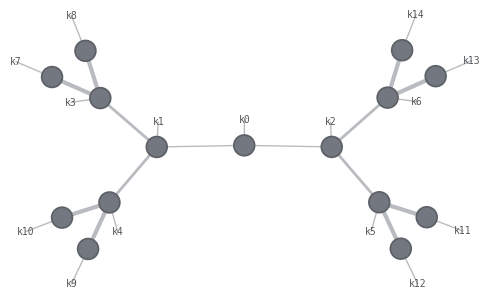

In [4]:
import quimb.tensor as qtn
import numpy as np

L = 15  # Nombre total de nœuds dans l'arbre

# Création des nœuds du réseau sous forme de tenseurs
tensors = [qtn.Tensor(data=1.0) for _ in range(L)]

# Organisation en structure d'arbre binaire avec tailles de liens constantes par niveau
for i in range(L):
    # Ajouter un indice physique à chaque tenseur (dimension 2)
    tensors[i].new_ind(f'k{i}', size=2)

    # Calcul de la profondeur du nœud actuel
    depth = int(np.floor(np.log2(i + 1)))

    # Connexion dans une structure d'arbre binaire
    left_child = 2 * i + 1
    right_child = 2 * i + 2

    if left_child < L:
        tensors[i].new_bond(tensors[left_child], size=2**(depth+1))  # Taille uniforme à profondeur constante
    if right_child < L:
        tensors[i].new_bond(tensors[right_child], size=2**(depth+1))  # Même taille pour tous les enfants

# Création du réseau de tenseurs sous forme d'arbre
tree_tn = qtn.TensorNetwork(tensors)

# Affichage avec mise en évidence de la racine
tree_tn.draw(show_inds=True, show_tags=False)


📌 Génération d'arbres de tenseurs avec différentes configurations...



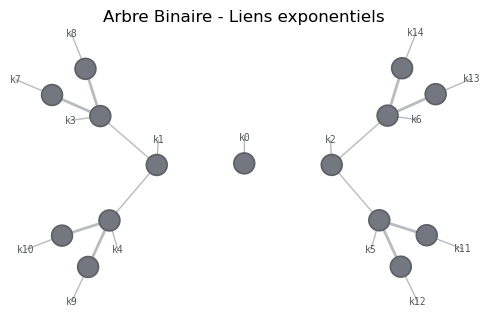

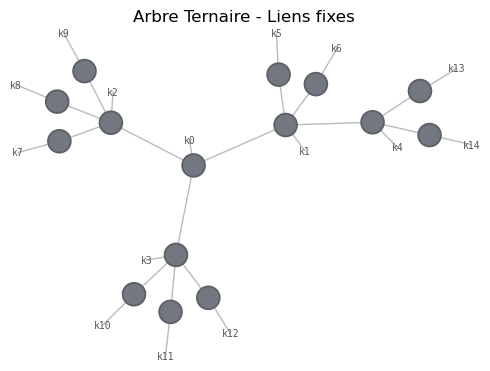

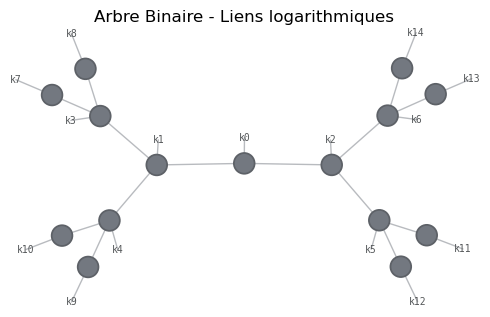

✅ Arbres générés avec succès !


In [ ]:
import quimb.tensor as qtn
import numpy as np


class TensorTreeGenerator:
    def __init__(self, L=15, branching_factor=2, phys_dim=2, bond_size_rule="exponential"):
        """
        Initialise le générateur d'arbres de tenseurs.
        
        - L : Nombre total de nœuds
        - branching_factor : Facteur de branchement (2 = binaire, 3 = ternaire, etc.)
        - phys_dim : Dimension physique de chaque tenseur
        - bond_size_rule : Règle de taille des liens ("fixed", "exponential", "logarithmic")
        """
        self.L = L
        self.branching_factor = branching_factor
        self.phys_dim = phys_dim
        self.bond_size_rule = bond_size_rule

    def compute_bond_size(self, depth):
        """Calcule la taille des liens en fonction de la profondeur et de la règle choisie."""
        if self.bond_size_rule == "fixed":
            return 2  # Taille constante pour tous les liens
        elif self.bond_size_rule == "exponential":
            return 2 ** depth  # Croissance exponentielle
        elif self.bond_size_rule == "logarithmic":
            return max(2, int(np.log2(depth + 2)))  # Croissance logarithmique
        else:
            raise ValueError("Règle de taille de lien inconnue ! Utilise 'fixed', 'exponential' ou 'logarithmic'.")

    def generate_tree(self):
        """Construit un réseau de tenseurs sous forme d'arbre."""
        tensors = [qtn.Tensor(data=1.0) for _ in range(self.L)]

        for i in range(self.L):
            # Ajouter un indice physique
            tensors[i].new_ind(f'k{i}', size=self.phys_dim)

            # Déterminer la profondeur du nœud
            depth = int(np.floor(np.log2(i + 1)))

            # Connexion avec les enfants
            for j in range(1, self.branching_factor + 1):
                child = self.branching_factor * i + j
                if child < self.L:
                    bond_size = self.compute_bond_size(depth)
                    tensors[i].new_bond(tensors[child], size=bond_size)

        return qtn.TensorNetwork(tensors)


# 🟢 Exemples d'utilisation :
if __name__ == "__main__":
    # Générer différents arbres
    print("Génération d'arbres de tenseurs avec différentes configurations\n")

    # 🔹 Arbre binaire avec croissance exponentielle des liens
    tree1 = TensorTreeGenerator(L=115, branching_factor=2, bond_size_rule="exponential").generate_tree()
    tree1.draw(title="Arbre Binaire - Liens exponentiels", show_inds=True)

    # 🔹 Arbre ternaire avec liens fixes
    tree2 = TensorTreeGenerator(L=15, branching_factor=3, bond_size_rule="fixed").generate_tree()
    tree2.draw(title="Arbre Ternaire - Liens fixes", show_inds=True)

    # 🔹 Arbre binaire avec liens logarithmiques
    tree3 = TensorTreeGenerator(L=15, branching_factor=2, bond_size_rule="logarithmic").generate_tree()
    tree3.draw(title="Arbre Binaire - Liens logarithmiques", show_inds=True)

    print("✅ Arbres générés avec succès !")
